Janeth Garcia Rodriguez Model Testing

In [11]:
from google.colab import files

uploaded = files.upload()

Saving adult.data to adult (1).data


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

all_columns = [
    'age',
    'workclass',
    'fnlwgt',
    'education',
    'education-num',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'native-country',
    'income'
]

df = pd.read_csv(
    'adult.data',
    header=None,
    names=all_columns
)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [13]:
print("Dataset shape:", df.shape)
print()

df.info()

Dataset shape: (32561, 15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [14]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [15]:
for column in df.columns:
    count = df[column].astype(str).str.strip().eq('?').sum()
    if count > 0:
        print(f"{column}: {count}")

workclass: 1836
occupation: 1843
native-country: 583


In [16]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 24


In [17]:
categorical_features = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country'
]

numerical_features = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

target_feature = 'income'

# Remove extra spaces from categorical columns and target
for column in categorical_features + [target_feature]:
    df[column] = df[column].str.strip()

# Convert ? into actual missing values
df.replace('?', np.nan, inplace=True)

In [18]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [19]:
df['income'].value_counts()

,count
income,
<=50K,24720
>50K,7841


In [20]:
df['income'].value_counts(normalize=True).mul(100).round(2)

,proportion
income,
<=50K,75.92
>50K,24.08


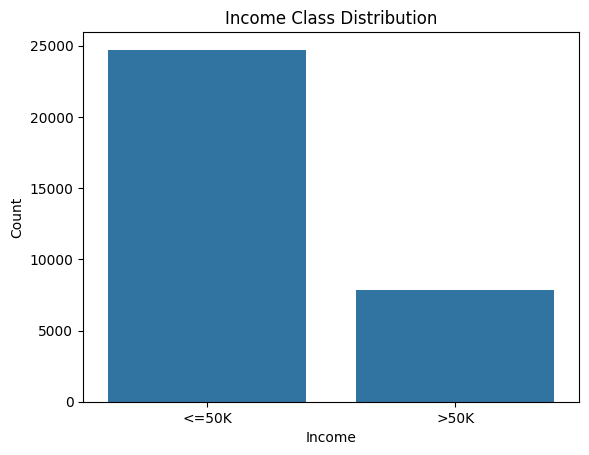

In [21]:
sns.countplot(data=df, x='income')

plt.title('Income Class Distribution')
plt.xlabel('Income')
plt.ylabel('Count')

plt.show()

In [22]:
df[numerical_features].describe().round(2)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.00,32561.00,32561.00,32561.00,32561.00,32561.00
mean,38.58,189778.37,10.08,1077.65,87.30,40.44
std,13.64,105549.98,2.57,7385.29,402.96,12.35
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117827.00,9.00,0.00,0.00,40.00
50%,37.00,178356.00,10.00,0.00,0.00,40.00
75%,48.00,237051.00,12.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


In [23]:
income_numeric_summary = df.groupby('income')[
    ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']
].mean().round(2)

income_numeric_summary

,age,education-num,hours-per-week,capital-gain,capital-loss
income,,,,,
<=50K,36.78,9.60,38.84,148.75,53.14
>50K,44.25,11.61,45.47,4006.14,195.00


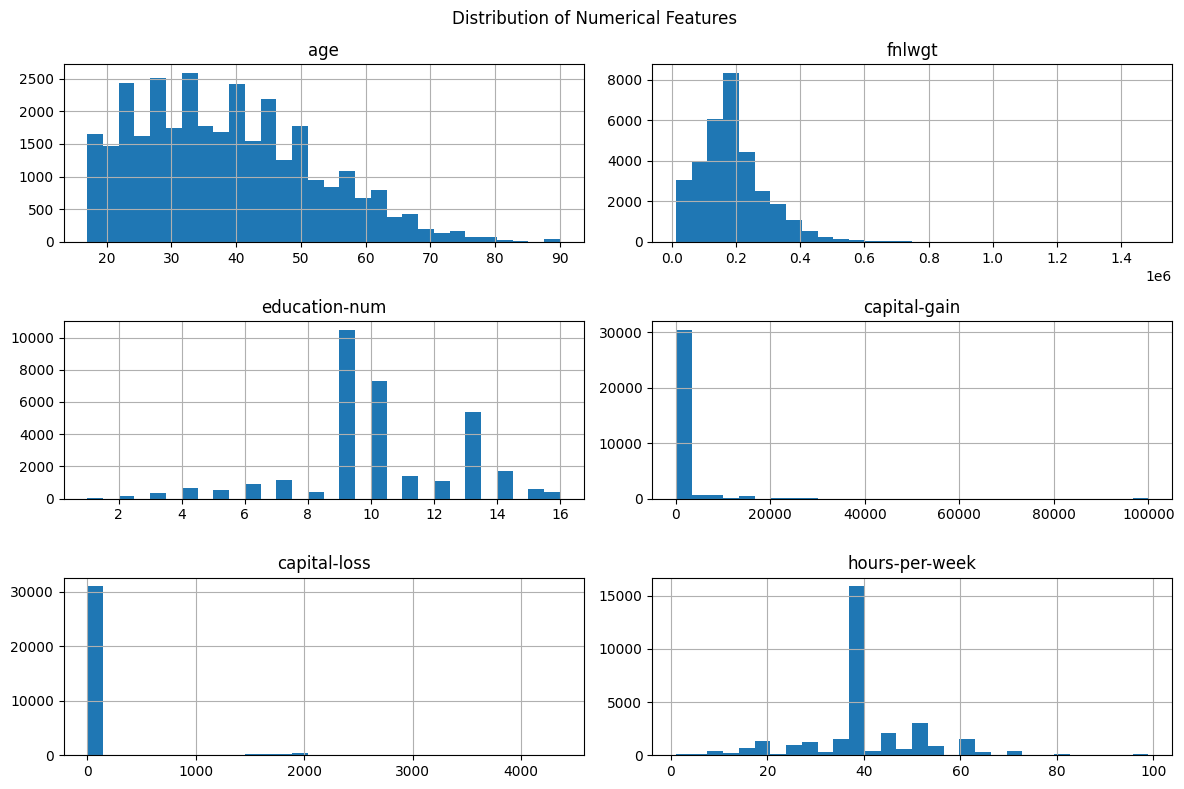

In [24]:
df[numerical_features].hist(
    figsize=(12, 8),
    bins=30
)

plt.suptitle('Distribution of Numerical Features')
plt.tight_layout()
plt.show()

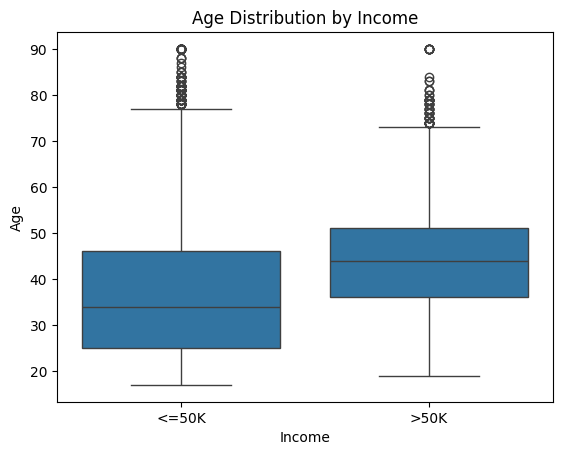

In [25]:
sns.boxplot(data=df, x='income', y='age')

plt.title('Age Distribution by Income')
plt.xlabel('Income')
plt.ylabel('Age')
plt.show()

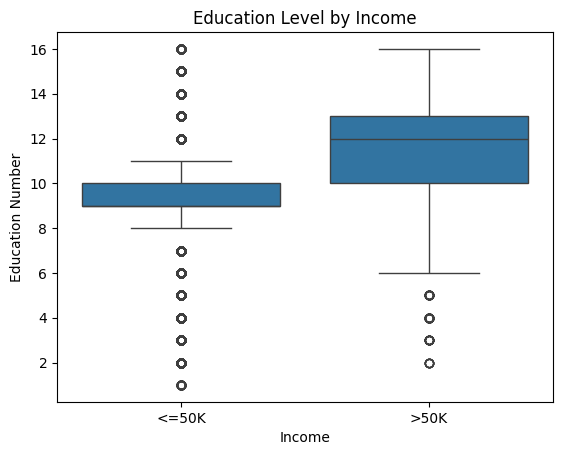

In [26]:
sns.boxplot(data=df, x='income', y='education-num')

plt.title('Education Level by Income')
plt.xlabel('Income')
plt.ylabel('Education Number')
plt.show()

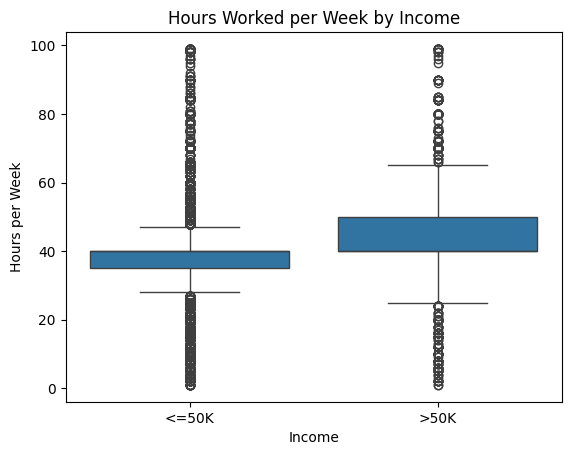

In [27]:
sns.boxplot(data=df, x='income', y='hours-per-week')

plt.title('Hours Worked per Week by Income')
plt.xlabel('Income')
plt.ylabel('Hours per Week')
plt.show()

In [28]:
education_income = pd.crosstab(
    df['education'],
    df['income'],
    normalize='index'
) * 100

education_income.round(2)

income,<=50K,>50K
education,,
10th,93.35,6.65
11th,94.89,5.11
12th,92.38,7.62
1st-4th,96.43,3.57
5th-6th,95.20,4.80
7th-8th,93.81,6.19
9th,94.75,5.25
Assoc-acdm,75.16,24.84
Assoc-voc,73.88,26.12


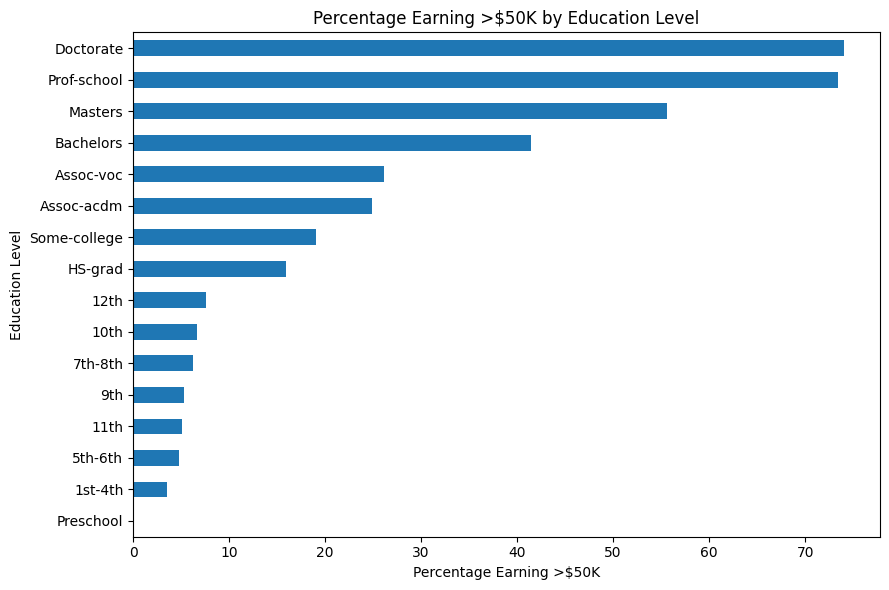

In [29]:
education_income['>50K'].sort_values().plot(
    kind='barh',
    figsize=(9, 6)
)

plt.title('Percentage Earning >$50K by Education Level')
plt.xlabel('Percentage Earning >$50K')
plt.ylabel('Education Level')
plt.tight_layout()
plt.show()

In [30]:
occupation_income = pd.crosstab(
    df['occupation'],
    df['income'],
    normalize='index'
) * 100

occupation_income.round(2)

income,<=50K,>50K
occupation,,
Adm-clerical,86.55,13.45
Armed-Forces,88.89,11.11
Craft-repair,77.34,22.66
Exec-managerial,51.60,48.40
Farming-fishing,88.43,11.57
Handlers-cleaners,93.72,6.28
Machine-op-inspct,87.51,12.49
Other-service,95.84,4.16
Priv-house-serv,99.33,0.67


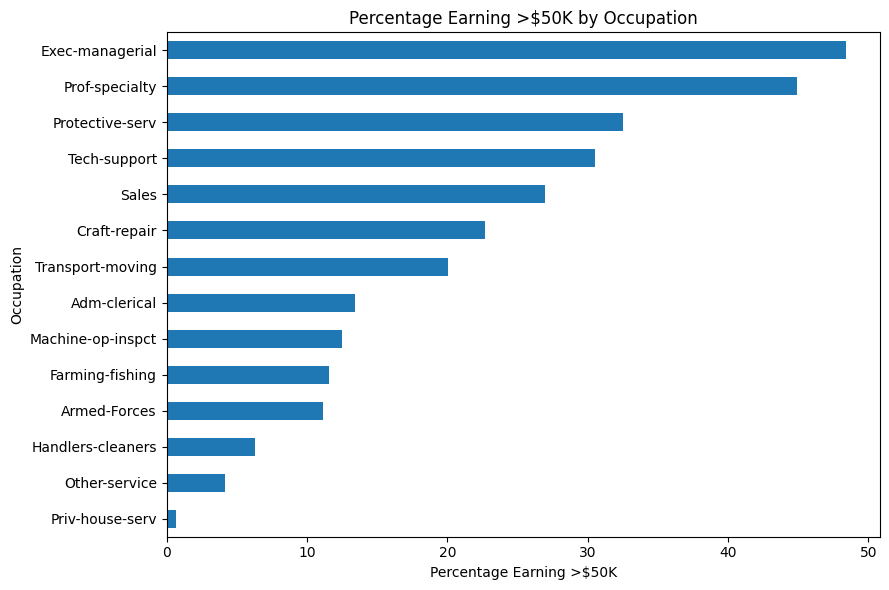

In [31]:
occupation_income['>50K'].sort_values().plot(
    kind='barh',
    figsize=(9, 6)
)

plt.title('Percentage Earning >$50K by Occupation')
plt.xlabel('Percentage Earning >$50K')
plt.ylabel('Occupation')
plt.tight_layout()
plt.show()

In [32]:
from sklearn.model_selection import train_test_split

X = df[categorical_features + numerical_features]

y = df[target_feature].apply(
    lambda x: 1 if x == '>50K' else 0
)

random_state_value = 48

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=random_state_value,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (26048, 14)
Testing set: (6513, 14)

Training target distribution:
income
0    19775
1     6273
Name: count, dtype: int64

Testing target distribution:
income
0    4945
1    1568
Name: count, dtype: int64


In [33]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [34]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [35]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [36]:
logistic_regression = LogisticRegression(
    max_iter=1000,
    random_state=random_state_value
)

lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', logistic_regression)
])

In [37]:
lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=48))])

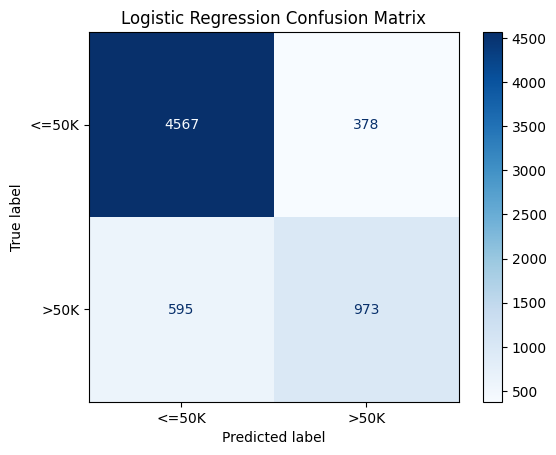

In [73]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

lr_confusion = confusion_matrix(y_test, lr_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=lr_confusion,
    display_labels=["<=50K", ">50K"]
)

disp.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [65]:
# Predictions from the original Logistic Regression model
lr_predictions = lr_model.predict(X_test)

lr_probabilities = lr_model.predict_proba(X_test)[:, 1]

# Cross-validation accuracy before tuning
lr_cv_accuracy = cross_val_score(
    lr_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
).mean()

print("Logistic Regression Pre-Tuning Accuracy:",
      accuracy_score(y_test, lr_predictions))

print("Logistic Regression Pre-Tuning Precision:",
      precision_score(y_test, lr_predictions))

print("Logistic Regression Pre-Tuning F1 Score:",
      f1_score(y_test, lr_predictions))

print("Logistic Regression Pre-Tuning ROC-AUC:",
      roc_auc_score(y_test, lr_probabilities))

print("Logistic Regression Pre-Tuning CV Accuracy:",
      lr_cv_accuracy)

Logistic Regression Pre-Tuning Accuracy: 0.8506064793489944
Logistic Regression Pre-Tuning Precision: 0.7202072538860104
Logistic Regression Pre-Tuning F1 Score: 0.6666666666666666
Logistic Regression Pre-Tuning ROC-AUC: 0.9077820309114545
Logistic Regression Pre-Tuning CV Accuracy: 0.8512745068055473


In [67]:
lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100]
}

lr_grid_search = GridSearchCV(
    estimator=lr_model,
    param_grid=lr_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

lr_grid_search.fit(X_train, y_train)

print("Best Logistic Regression Parameters:")
print(lr_grid_search.best_params_)

print("\nBest Logistic Regression CV Accuracy:")
print(lr_grid_search.best_score_)

Best Logistic Regression Parameters:
{'classifier__C': 0.1}

Best Logistic Regression CV Accuracy:
0.8515816895974744


In [68]:
lr_tuned_model = lr_grid_search.best_estimator_

lr_tuned_predictions = lr_tuned_model.predict(X_test)

lr_tuned_probabilities = lr_tuned_model.predict_proba(X_test)[:, 1]

lr_tuned_cv_accuracy = cross_val_score(
    lr_tuned_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
).mean()

print("Logistic Regression Post-Tuning Accuracy:",
      accuracy_score(y_test, lr_tuned_predictions))

print("Logistic Regression Post-Tuning Precision:",
      precision_score(y_test, lr_tuned_predictions))

print("Logistic Regression Post-Tuning F1 Score:",
      f1_score(y_test, lr_tuned_predictions))

print("Logistic Regression Post-Tuning ROC-AUC:",
      roc_auc_score(y_test, lr_tuned_probabilities))

print("Logistic Regression Post-Tuning CV Accuracy:",
      lr_tuned_cv_accuracy)

Logistic Regression Post-Tuning Accuracy: 0.8504529402732995
Logistic Regression Post-Tuning Precision: 0.722972972972973
Logistic Regression Post-Tuning F1 Score: 0.6641379310344827
Logistic Regression Post-Tuning ROC-AUC: 0.907520351416603
Logistic Regression Post-Tuning CV Accuracy: 0.8515816895974744


In [41]:
from sklearn.naive_bayes import GaussianNB

categorical_transformer_nb = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

numerical_transformer_nb = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor_nb = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_nb, numerical_features),
        ('cat', categorical_transformer_nb, categorical_features)
    ]
)

In [42]:
naive_bayes = GaussianNB()

nb_model = Pipeline(steps=[
    ('preprocessor', preprocessor_nb),
    ('classifier', naive_bayes)
])

In [43]:
nb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('classifier', GaussianNB())])

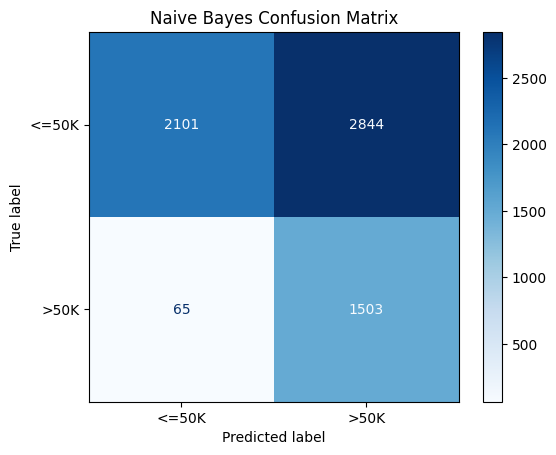

In [74]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

nb_confusion = confusion_matrix(y_test, nb_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=nb_confusion,
    display_labels=["<=50K", ">50K"]
)

disp.plot(cmap="Blues")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [69]:
# Predictions from the original Naive Bayes model
nb_predictions = nb_model.predict(X_test)

nb_probabilities = nb_model.predict_proba(X_test)[:, 1]

# Cross-validation accuracy before tuning
nb_cv_accuracy = cross_val_score(
    nb_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
).mean()

print("Naive Bayes Pre-Tuning Accuracy:",
      accuracy_score(y_test, nb_predictions))

print("Naive Bayes Pre-Tuning Precision:",
      precision_score(y_test, nb_predictions))

print("Naive Bayes Pre-Tuning F1 Score:",
      f1_score(y_test, nb_predictions))

print("Naive Bayes Pre-Tuning ROC-AUC:",
      roc_auc_score(y_test, nb_probabilities))

print("Naive Bayes Pre-Tuning CV Accuracy:",
      nb_cv_accuracy)

Naive Bayes Pre-Tuning Accuracy: 0.5533548288039306
Naive Bayes Pre-Tuning Precision: 0.34575569358178054
Naive Bayes Pre-Tuning F1 Score: 0.5081994928148774
Naive Bayes Pre-Tuning ROC-AUC: 0.773363116733043
Naive Bayes Pre-Tuning CV Accuracy: 0.54211224556347


In [70]:
nb_param_grid = {
    'classifier__var_smoothing': np.logspace(-12, -6, 7)
}

nb_grid_search = GridSearchCV(
    estimator=nb_model,
    param_grid=nb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

nb_grid_search.fit(X_train, y_train)

print("Best Naive Bayes Parameters:")
print(nb_grid_search.best_params_)

print("\nBest Naive Bayes CV Accuracy:")
print(nb_grid_search.best_score_)

Best Naive Bayes Parameters:
{'classifier__var_smoothing': np.float64(1e-06)}

Best Naive Bayes CV Accuracy:
0.6023097481142374


In [71]:
nb_tuned_model = nb_grid_search.best_estimator_

nb_tuned_predictions = nb_tuned_model.predict(X_test)

nb_tuned_probabilities = nb_tuned_model.predict_proba(X_test)[:, 1]

nb_tuned_cv_accuracy = cross_val_score(
    nb_tuned_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
).mean()

print("Naive Bayes Post-Tuning Accuracy:",
      accuracy_score(y_test, nb_tuned_predictions))

print("Naive Bayes Post-Tuning Precision:",
      precision_score(y_test, nb_tuned_predictions))

print("Naive Bayes Post-Tuning F1 Score:",
      f1_score(y_test, nb_tuned_predictions))

print("Naive Bayes Post-Tuning ROC-AUC:",
      roc_auc_score(y_test, nb_tuned_probabilities))

print("Naive Bayes Post-Tuning CV Accuracy:",
      nb_tuned_cv_accuracy)

Naive Bayes Post-Tuning Accuracy: 0.6069399662214033
Naive Bayes Post-Tuning Precision: 0.3741116751269036
Naive Bayes Post-Tuning F1 Score: 0.5352214960058097
Naive Bayes Post-Tuning ROC-AUC: 0.8310805338313283
Naive Bayes Post-Tuning CV Accuracy: 0.6023097481142374


In [72]:
all_tuning_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression",
        "Naive Bayes",
        "Naive Bayes"
    ],

    "Stage": [
        "Pre-Tuning",
        "Post-Tuning",
        "Pre-Tuning",
        "Post-Tuning"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, lr_tuned_predictions),
        accuracy_score(y_test, nb_predictions),
        accuracy_score(y_test, nb_tuned_predictions)
    ],

    "Precision": [
        precision_score(y_test, lr_predictions),
        precision_score(y_test, lr_tuned_predictions),
        precision_score(y_test, nb_predictions),
        precision_score(y_test, nb_tuned_predictions)
    ],

    "F1 Score": [
        f1_score(y_test, lr_predictions),
        f1_score(y_test, lr_tuned_predictions),
        f1_score(y_test, nb_predictions),
        f1_score(y_test, nb_tuned_predictions)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, lr_probabilities),
        roc_auc_score(y_test, lr_tuned_probabilities),
        roc_auc_score(y_test, nb_probabilities),
        roc_auc_score(y_test, nb_tuned_probabilities)
    ],

    "Cross-Validation Accuracy": [
        lr_cv_accuracy,
        lr_tuned_cv_accuracy,
        nb_cv_accuracy,
        nb_tuned_cv_accuracy
    ]
})

all_tuning_comparison.round(4)

,Model,Stage,Accuracy,Precision,F1 Score,ROC-AUC,Cross-Validation Accuracy
0,Logistic Regression,Pre-Tuning,0.8506,0.7202,0.6667,0.9078,0.8513
1,Logistic Regression,Post-Tuning,0.8505,0.7230,0.6641,0.9075,0.8516
2,Naive Bayes,Pre-Tuning,0.5534,0.3458,0.5082,0.7734,0.5421
3,Naive Bayes,Post-Tuning,0.6069,0.3741,0.5352,0.8311,0.6023
